In [1]:
import numpy as np
from collections import Counter
import random
import pandas as pd

In [3]:
P_fail = {1: 4/6, 2: 0.4444444444444444, 3: 0.2777777777777778, 4: 0.1574074074074074, 5: 0.07716049382716049, 6: 0.030864197530864196}

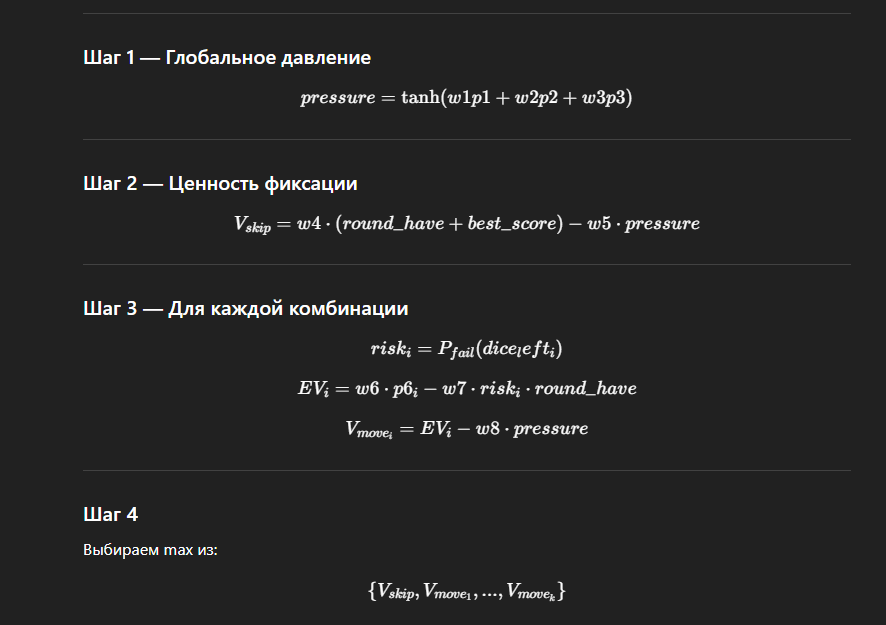

In [ ]:
class Player():
    def __init__(self, w=[random.random() for _ in range(16)]) -> None:
        self.w1 = w[0]
        self.w2 = w[1]
        self.w3 = w[2]
        self.w4 = w[3]
        self.w5 = w[4]
        self.w6 = w[5]
        self.w7 = w[6]
        self.w8 = w[7]
        self.w9 = w[8]
        self.w10 = w[9]
        self.w11 = w[10]
        self.w12 = w[11]
        self.w13 = w[12]
        self.w14 = w[13]
        self.w15 = w[14]
        self.w16 = w[15]

        self.W = w

        self.path = []
        self.stats = {'move': 0, 'skip': 0, 'lose': 0, 'sum': 0}

    def get_w(self):
        return self.W
    
    def get_stats(self, talk=False):
        if not self.path:
            return pd.Series({'move': 0, 'skip': 0, 'lose': 0}, dtype=int)

        #df = pd.DataFrame(self.path)
        stats = pd.DataFrame(self.path)[6].apply(lambda x: 'move' if isinstance(x, tuple) else x).value_counts()

        required_keys = ['move', 'skip', 'lose']

        for key in required_keys:
            if key not in stats:
                stats[key] = 0

        if talk:
            print(stats)

        return stats    

    def make_decision(self, total, you_have, opponent_have, dice_count, round_have, comb_list):
        p1 = total - you_have
        p2 = total - opponent_have
        p3 = you_have - opponent_have
        best_score = max([score for score, _ in comb_list])

        pressure = np.tanh(self.W[0]*p1 + self.W[1]*p2 + self.W[2]*p3)

        V_skip = self.W[3] * (round_have + best_score) - self.W[4] * pressure

        risk_i = []

        choose = []
        choose.append(("skip", ))

        choose = []
        choose.append(("skip", self.w6 * (self.w1*total + self.w2*you_have + self.w3*opponent_have + self.w4*dice_count + self.w5*round_have + sum([self.w7*s + self.w8*d for s,d in comb_list]))))
        for s, d in comb_list:
            choose.append(((s, d), self.w16 * (self.w9*total + self.w10*you_have + self.w11*opponent_have + self.w12*dice_count + self.w13*round_have + self.w14*s + self.w15*d)))

        return max(choose, key=lambda x: x[1])
